# 06 - Services integration (YOLOX + BreastSegmentation)

Este notebook usa `api_stable.MammographyDicom` como pipeline de imagen y prueba inferencia remota contra `yolox-api` y `maseg-api`.

In [1]:
import os
from pathlib import Path
import base64

import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

from api_stable.mammography import MammographyDicom

In [2]:
# os.listdir('/workspace/Data/INbreast/AllDICOMs')
os.listdir('/workspace/Data/NL-breast/abnormal/p_4444/left-c/MLO/')

['IM-0180-0004-0001.dcm']

In [3]:
# Ajusta esta ruta a un DICOM real de tu dataset montado en el contenedor.
# DICOM_PATH = Path('/workspace/Data/INbreast/AllDICOMs/22580367_5eae9beae14d26fd_MG_L_CC_ANON.dcm')
DICOM_PATH = Path('/workspace/Data/NL-breast/abnormal/p_4444/left-c/MLO/IM-0180-0004-0001.dcm')

if not DICOM_PATH.exists():
    raise FileNotFoundError(f'No existe DICOM_PATH: {DICOM_PATH}')

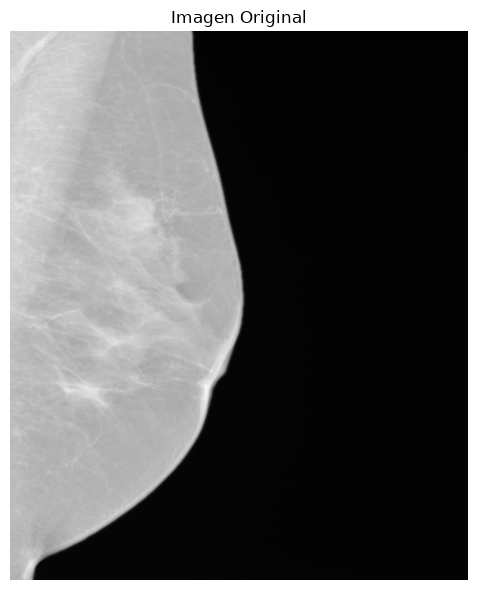

In [4]:
mammo = MammographyDicom.from_dicom(DICOM_PATH)
image = mammo.image.to_numpy()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(image, cmap='gray')
ax.set_title('Imagen Original')
ax.axis('off')
plt.tight_layout()

In [5]:
print(mammo.metadata)

MammographyMetadata(patient=PatientInfo(patient_id='', age=74, sex='F'), vendor=VendorInfo(manufacturer='GE MEDICAL SYSTEMS', model_name='Senographe Essential VERSION ADS_53.40'), acquisition=AcquisitionInfo(kvp='29', exposure='57', exposure_time='920', tube_current='62', compression_force='90'), breast=BreastInfo(laterality='L', view='MLO', breast_implant_present=False), image=ImageInfo(rows=2294, columns=1914, bits_stored=12, pixel_spacing=None, photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=[2539, 2587, 2473], window_width=[900, 750, 1050], window_center_width_explanation=['NORMAL', 'HARDER', 'SOFTER'], voi_lut_function='SIGMOID'))


In [6]:
mammo = MammographyDicom.from_dicom(DICOM_PATH).initialize_image().normalize()
arr = mammo.image.to_numpy().astype(np.float32)

arr_min, arr_max = float(arr.min()), float(arr.max())
if arr_max > arr_min:
    arr = (arr - arr_min) / (arr_max - arr_min)
image_uint8 = (arr * 255.0).clip(0, 255).astype(np.uint8)

print('DICOM cargado:', DICOM_PATH)
print('Shape:', image_uint8.shape, 'dtype:', image_uint8.dtype)
print('History:', mammo.image.get_history())

151.51515 2878.2769
1726.9814 767.5303
151.51515 2878.2769
1726.9814 767.5303
0.050002266 0.94987434
0.56992966 0.25329646
0.050002266 0.94987434
0.56992966 0.25329646
DICOM cargado: /workspace/Data/NL-breast/abnormal/p_4444/left-c/MLO/IM-0180-0004-0001.dcm
Shape: (2294, 1914) dtype: uint8
History: ['apply_windowing( window_center=2539, window_width=900, voi_lut_function=SIGMOID)', 'normalize']


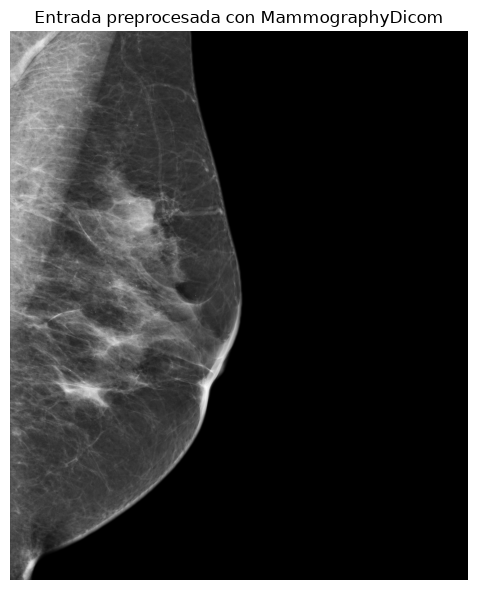

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(arr, cmap='gray')
ax.set_title('Entrada preprocesada con MammographyDicom')
ax.axis('off')
plt.tight_layout()

In [8]:
in_docker = Path('/.dockerenv').exists()
default_yolox = 'http://yolox-api:8001' if in_docker else 'http://localhost:8001'
default_maseg = 'http://maseg-api:8002' if in_docker else 'http://localhost:8002'

YOLOX_API_BASE = os.getenv('YOLOX_API_BASE', default_yolox)
MASEG_API_BASE = os.getenv('MASEG_API_BASE', default_maseg)

print('Kernel en docker:', in_docker)
print('YOLOX_API_BASE:', YOLOX_API_BASE)
print('MASEG_API_BASE:', MASEG_API_BASE)

for name, base in [('YOLOX', YOLOX_API_BASE), ('MASEG', MASEG_API_BASE)]:
    r = requests.get(f'{base}/health', timeout=30)
    print(name, 'health ->', r.status_code, r.text)

Kernel en docker: True
YOLOX_API_BASE: http://yolox-api:8001
MASEG_API_BASE: http://maseg-api:8002
YOLOX health -> 200 {"status":"ok","service":"yolox"}
MASEG health -> 200 {"status":"ok","service":"maseg"}


In [9]:
ok, encoded_png = cv2.imencode('.png', image_uint8)
if not ok:
    raise RuntimeError('No se pudo codificar image_uint8 a PNG')
payload = encoded_png.tobytes()

resp_yolo = requests.post(
    f'{YOLOX_API_BASE}/infer',
    files={'file': ('image.png', payload, 'image/png')},
    data={'input_format': 'BGR'},
    timeout=120,
)
print('YOLOX status:', resp_yolo.status_code)
if resp_yolo.ok:
    yolo_json = resp_yolo.json()
    print('YOLOX detecciones:', yolo_json.get('num_detections'))
    print('Primera deteccion:', (yolo_json.get('detections') or [None])[0])
else:
    print(resp_yolo.text)

YOLOX status: 200
YOLOX detecciones: 1
Primera deteccion: {'bbox_xyxy': [7.216855049133301, 138.87745666503906, 988.07763671875, 2225.889892578125], 'score': 0.9884754419326782, 'class_id': 0, 'class_name': 'person'}


In [11]:
from matplotlib.patches import Rectangle
print(yolo_json.get('num_detections'))

1


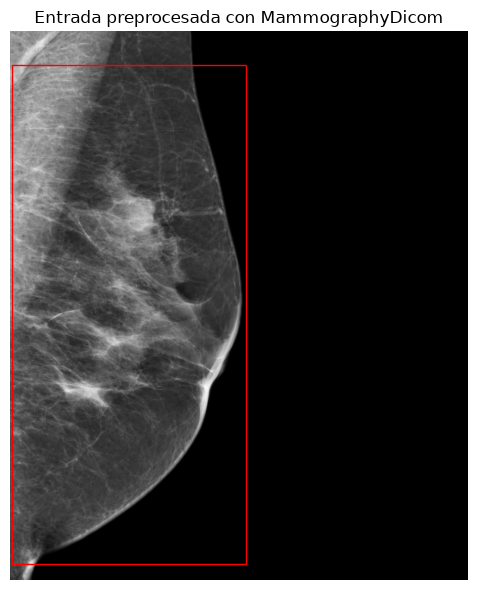

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(arr, cmap='gray')
for i in range(yolo_json.get('num_detections')):
    xmin,ymin,xmax,ymax = yolo_json.get('detections')[i]['bbox_xyxy']
    rect = Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=1,
                              edgecolor='r', facecolor='none')
    ax.add_patch(rect)

ax.set_title('Entrada preprocesada con MammographyDicom')
ax.axis('off')
plt.tight_layout()

In [13]:
resp_maseg = requests.post(
    f'{MASEG_API_BASE}/infer',
    files={'file': ('image.png', payload, 'image/png')},
    data={'include_pectoral_mask': True, 'fill_holes_in_breast': True},
    timeout=120,
)
print('MAseg status:', resp_maseg.status_code)
if resp_maseg.ok:
    maseg_json = resp_maseg.json()
    print('MAseg summary:', maseg_json.get('summary'))

    b64_png = maseg_json.get('pectoral_mask_png_base64')
    if b64_png:
        mask_png = base64.b64decode(b64_png)
        mask_arr = np.frombuffer(mask_png, dtype=np.uint8)
        mask = cv2.imdecode(mask_arr, cv2.IMREAD_GRAYSCALE)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(image_uint8, cmap='gray')
        axes[0].set_title('Entrada')
        axes[0].axis('off')

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title('Mascara pectoral (API)')
        axes[1].axis('off')
        plt.tight_layout()
else:
    print(resp_maseg.text)

MAseg status: 500
Internal Server Error
